# High-Dimensional Bayesian Optimization with SAASBO

[_Link to Tutorial on BoTorch_](https://botorch.org/docs/tutorials/saasbo/)

_Drew Gjerstad_

**Includes content from BoTorch's documentation.**

In this tutorial, we review how to implement **Sparse Axis-Aligned Subspace Bayesian Optimization** ([SAASBO](https://proceedings.mlr.press/v161/eriksson21a.html)) for high-dimensional Bayesian optimization. The SAASBO method avoids the over-fitting in high-dimensional spaces by placing strong priors on the inverse lengthscales. In particular, SAASBO makes use of a hierarchical sparsity prior incorporating a global shrinkage parameter $\tau\sim\mathcal{HC}(\beta)$ and inverse lengthscales $\rho_{d}\sim\mathcal{HC}(\tau)$ for $d=1,\dots,D$ where $\mathcal{HC}$ denotes the half-Cauchy distribution. While the half-Cauchy distribution favors values near zero, they also have heavy tails that help the inverse lengthscales for the most important parameters to avoid zero.

The tutorial's author notes that for performing inference in the SAAS model we will use Hamiltonian Monte Carlo (HMC) as it was found to outperform MAP inference. In addition, SAASBO performs well for problems with hundreds of dimensions but since we are relying on HMC for inference, SAASBO's overhead scales cubically with the number of samples. Thus, depending on the problem, using more than a few hundred samples may be infeasible due to SAASBO's design being advantageous for problems with limited evaluation budget.

## Setup
First, we load the necessary dependencies and set keyword arguments for tensors.

In [18]:
# Load Dependencies
import sys
import os

import torch
from torch.quasirandom import SobolEngine

from botorch import fit_fully_bayesian_model_nuts
from botorch.acquisition.logei import qLogExpectedImprovement
from botorch.models.fully_bayesian import SaasFullyBayesianSingleTaskGP
from botorch.models.transforms import Standardize
from botorch.optim import optimize_acqf
from botorch.test_functions import Branin

SMOKE_TEST = os.environ.get("SMOKE_TEST")

In [2]:
# Define Tensor Keyword Arguments
tkwargs = {
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "dtype": torch.double
}

## Special Note on Optimization Warm-Up and Number of Samples
To avoid increased overhead and decrease the time it takes to fit the SAAS model by lowering `WARMUP_STEPS` and `NUM_SAMPLES`. The author recommends using 512 warmup steps and 256 samples when possible and avoid using less than 256 warmup steps and 128 samples. The default practice is to only keep each 16th sample meaning for 256 samples results in 32 hyperparameter samples (this is controlled via the `THINNING` variable below).

To keep this tutorial efficient, the author uses 256 warmup steps and 128 samples.

In [3]:
WARMUP_STEPS = 256 if not SMOKE_TEST else 32
NUM_SAMPLES = 128 if not SMOKE_TEST else 16
THINNING = 16

## Fitting a Simple Model
Next, we start by reviewing how to fit a simple model. To do this, we generate a simple function that is only dependent on the first parameter to demonstrate that the SAAS model sets all other lengthscales to large values.

In [4]:
# Generate Simple Function
train_X = torch.rand(10, 4, **tkwargs)
test_X = torch.rand(5, 4, **tkwargs)
train_Y = torch.sin(train_X[:, :1])
test_Y = torch.sin(test_X[:, :1])

Typically, we will infer the _unknown_ noise variance in the data. However, we can specify the known noise variant (`train_Yvar`) for each observation. This is particularly useful if we know that the problem is noise-free and we can set the noise variant to a small value such as `1e-6`. Then, we can construct a model for this case as shown in the next code cell.

In [5]:
# Construct GP Model (known noise variant)
gp = SaasFullyBayesianSingleTaskGP(train_X=train_X,
                                   train_Y=train_Y,
                                   train_Yvar=torch.full_like(train_Y, 1e-6))

/Users/drewgjerstad/miniconda3/envs/bo-env/lib/python3.11/site-packages/botorch/models/utils/assorted.py:273: InputDataWarning: Data (outcome observations) is not standardized (std = tensor([0.2297], dtype=torch.float64), mean = tensor([0.4969], dtype=torch.float64)).Please consider scaling the input to zero mean and unit variance.
  check_standardization(Y=train_Y, raise_on_fail=raise_on_fail)


## Define and Fit SAAS Gaussian Process Model
In the next code cell, we define the model for this tutorial and example.

In [6]:
# Construct GP Model
gp = SaasFullyBayesianSingleTaskGP(train_X=train_X,
                                   train_Y=train_Y,
                                   outcome_transform=Standardize(m=1))

fit_fully_bayesian_model_nuts(
    gp,
    warmup_steps=WARMUP_STEPS,
    num_samples=NUM_SAMPLES,
    thinning=THINNING,
    disable_progbar=True,
)

with torch.no_grad():
    posterior = gp.posterior(test_X)

To show that the first feature has the smallest lengthscale, we can compute the median lengthscales over the MCMC dimensions.

In [7]:
print(gp.median_lengthscale.detach())

tensor([ 2.1050, 31.2491, 13.4260, 27.1619], dtype=torch.float64)


## Use Model to Make Predictions
Now that the model is trained, we can use it to make predictions. In the cell below, we make predictions with the SAAS model in the same fashion as other posteriors in BoTorch: computing the mean and variance for test points. Note that the mean and posterior tensors have an extra batch dimension at -3 corresponding to the number of MCMC samples (8 in this tutorial).

In [8]:
# Print Dimensions of Posterior Mean and Variance
print(posterior.mean.shape)
print(posterior.variance.shape)

torch.Size([8, 5, 1])
torch.Size([8, 5, 1])


Additionally, BoTorch also provides methods to easily compute different statistics across the MCMC samples, as shown below.

In [9]:
# Compute Statistics over MCMC Samples
mixture_mean = posterior.mixture_mean
mixture_variance = posterior.mixture_variance
mixture_quantile = posterior.quantile(torch.tensor(0.95))

print(f"Ground Truth:   {test_Y.squeeze(-1)}")
print(f"Mixture Mean:   {mixture_mean.squeeze(-1)}")

Ground Truth:   tensor([0.0968, 0.8014, 0.7872, 0.3648, 0.4570], dtype=torch.float64)
Mixture Mean:   tensor([0.0997, 0.8006, 0.7863, 0.3653, 0.4562], dtype=torch.float64)


## Optimize the 30-dimensional Branin Function
Since we have an understanding of how to implement SAASBO using BoTorch, we can apply the method to optimize Branin embedded in a 30-dimensional space. Specifically, we embed the standard two-dimensional Branin problem in a 30-dimensional space with dimensions 0 and 1 corresponding to the true dimensions. This exercise demonstrates that SAASBO can identify the critical dimensions and optimize this function efficiently. Note that we will work with the domain $[0,1]^d$ and unnormalize the inputs to true domain of Branin before we evaluate the function.

In [10]:
# Prepare Branin Problem
branin = Branin().to(**tkwargs)

def branin_emb(x):
    """x is assumed to be in [0, 1]^d"""
    lb, ub = branin.bounds
    return branin(lb + (ub - lb) * x[..., :2])

In the next cell, we define the dimensions and evaluation budget.

In [11]:
# Define Problem Dimensions
DIM = 30 if not SMOKE_TEST else 2

# Define Evaluation Budget
N_INIT = 10
N_ITERATIONS = 8 if not SMOKE_TEST else 1
BATCH_SIZE = 5 if not SMOKE_TEST else 1
print(f"Using a total of {N_INIT + BATCH_SIZE * N_ITERATIONS} function evaluations")

Using a total of 50 function evaluations


We can now run the optimization with 10 initial Sobol (a type of sampling) points and then 8 iterations of Bayesian optimization using the batch size of 5 defined above, resulting in a total of 50 function evaluations. Note that we will flip the sign of the function values before fitting the SAAS model since our focus is minimizing Branin. This is due to the fact that in BoTorch, the acquisition functions assume maximization.

In [12]:
X = SobolEngine(dimension=DIM, scramble=True, seed=0).draw(N_INIT).to(**tkwargs)
Y = branin_emb(X).unsqueeze(-1)
print(f"Best initial point: {Y.min().item():.3f}")

for i in range(N_ITERATIONS):
    train_Y = -1 * Y  # Flip sign to minimize the function
    gp = SaasFullyBayesianSingleTaskGP(
        train_X=X,
        train_Y=train_Y,
        train_Yvar=torch.full_like(train_Y, 1e-6),
        outcome_transform=Standardize(m=1),
    )
    fit_fully_bayesian_model_nuts(
        gp,
        warmup_steps=WARMUP_STEPS,
        num_samples=NUM_SAMPLES,
        thinning=THINNING,
        disable_progbar=True,
    )

    # Use the Batch Log Expected Improvement (EI) Acquisition Function
    EI = qLogExpectedImprovement(model=gp, best_f=train_Y.max())
    candidates, acq_values = optimize_acqf(
        EI,
        bounds=torch.cat((torch.zeros(1, DIM), torch.ones(1, DIM))),
        q=BATCH_SIZE,
        num_restarts=10,
        raw_samples=1024,
    )

    # Get Next Set of Function Evaluations
    Y_next = torch.cat([branin_emb(x).unsqueeze(-1) for x in candidates]).unsqueeze(-1)
    if Y_next.min() < Y.min():
        ind_best = Y_next.argmin()
        x0, x1 = candidates[ind_best, :2].tolist()
        print(
            f"{i+1}) New Best: {Y_next[ind_best].item():.3f} @"
            f"[{x0:.3f}, {x1:.3f}]"
        )
    X = torch.cat((X, candidates))
    Y = torch.cat((Y, Y_next))

Best initial point: 5.322
3) New Best: 1.991 @[1.000, 0.186]
4) New Best: 1.690 @[0.511, 0.210]
5) New Best: 0.498 @[0.540, 0.134]
6) New Best: 0.433 @[0.956, 0.165]
7) New Best: 0.399 @[0.543, 0.153]


From the output above, we were able to get relatively close to the global optimum of $\approx 0.398$ after only 50 function evaluations. However, it is best practice to plot these results to see how optimization progressed across the iterations in the evaluation budget.

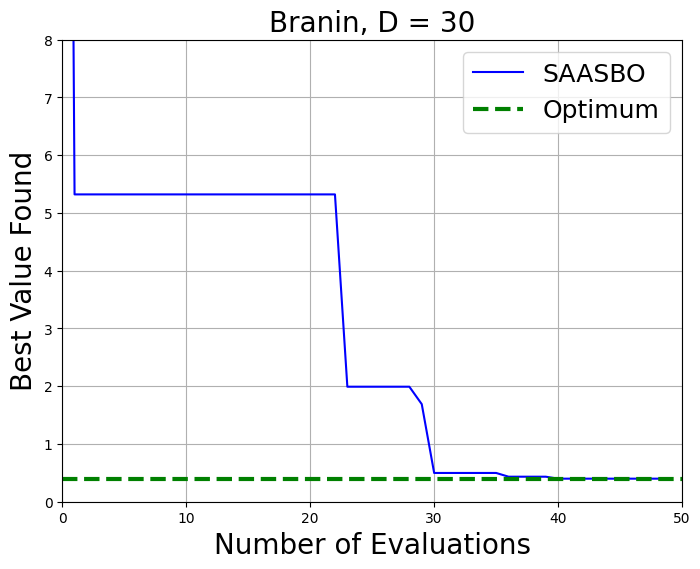

In [13]:
# Plot Results
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

Y_np = Y.cpu().numpy()
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(np.minimum.accumulate(Y_np), color="b", label="SAASBO")
ax.plot([0, len(Y_np)], [0.398, 0.398], "--", c="g", lw=3, label="Optimum")
ax.grid(True)
ax.set_title(f"Branin, D = {DIM}", fontsize=20)
ax.set_xlabel("Number of Evaluations", fontsize=20)
ax.set_xlim([0, len(Y_np)])
ax.set_ylabel("Best Value Found", fontsize=20)
ax.set_ylim([0, 8])
ax.legend(fontsize=18)
plt.show()

## Refit Model, Test on Out-of-Sample Points
Below, we will refit the model on 50 points and then predict 50 test points to determine how well the SAAS model predicts out-of-sample points. Additionally, we will also plot these predictions against their true values in addition to a 95% confidence interval for each test point.

In [14]:
# Initialize New Dataset for Training and Testing
train_X = SobolEngine(dimension=DIM, scramble=True, seed=0).draw(50).to(**tkwargs)
test_X = SobolEngine(dimension=DIM, scramble=True, seed=1).draw(50).to(**tkwargs)
train_Y = branin_emb(train_X).unsqueeze(-1)
test_Y = branin_emb(test_X).unsqueeze(-1)

# Define GP Model
gp = SaasFullyBayesianSingleTaskGP(
    train_X=train_X,
    train_Y=train_Y,
    train_Yvar=torch.full_like(train_Y, 1e-6),
    outcome_transform=Standardize(m=1),
)

# Fit Bayesian Model Using No-U-Turn-Sampler (NUTS)
fit_fully_bayesian_model_nuts(
    gp,
    warmup_steps=WARMUP_STEPS,
    num_samples=NUM_SAMPLES,
    thinning=THINNING,
    disable_progbar=True,
)

In [15]:
# Compute Posterior Distribution
with torch.no_grad():
    posterior = gp.posterior(test_X)

# Compute Quantiles for Points and their CIs
median = posterior.quantile(value=torch.tensor([0.5], **tkwargs))
q1 = posterior.quantile(value=torch.tensor([0.025], **tkwargs))
q2 = posterior.quantile(value=torch.tensor([0.975], **tkwargs))

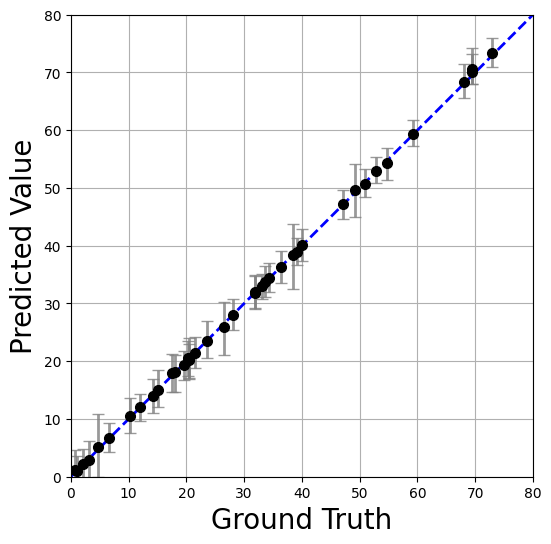

In [16]:
# Plot OOS Prediction Performance
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot([0, 80], [0, 80], "b--", lw=2)

y_err1, y_err2 = median - q1, q2 - median
y_err = torch.cat((y_err1.unsqueeze(0), y_err2.unsqueeze(0)), dim=0).squeeze(-1)
markers, caps, bars = ax.errorbar(
    test_Y.squeeze(-1).cpu().numpy(),
    median.squeeze(-1).cpu().numpy(),
    yerr=y_err.cpu().numpy(),
    fmt=".",
    capsize=4,
    elinewidth=2.0,
    ms=14,
    c="k",
    ecolor="gray",
)
ax.set_xlim([0, 80])
ax.set_ylim([0, 80])
[bar.set_alpha(0.8) for bar in bars]
[cap.set_alpha(0.8) for cap in caps]
ax.set_xlabel("Ground Truth", fontsize=20)
ax.set_ylabel("Predicted Value", fontsize=20)
ax.set_aspect("equal")
ax.grid(True)

## Inspect Lengthscales
Finally, let's inspect the lengthscales from our final model since we expect that only the first two parameters (0 and 1) to be identified as important by the SAASBO model. This is confirmed below since the lengthscales for the first two parameters are small while the other lengthscales are large.

In [17]:
# Inspect Final Model Lengthscales
median_lengthscales = gp.median_lengthscale
for i in median_lengthscales.argsort()[:10]:
    print(f"Parameter{i:2}) Median Lengthscale = {median_lengthscales[i].item():.2e}")

Parameter 0) Median Lengthscale = 7.19e-01
Parameter 1) Median Lengthscale = 2.27e+00
Parameter17) Median Lengthscale = 4.68e+02
Parameter18) Median Lengthscale = 4.78e+02
Parameter28) Median Lengthscale = 4.89e+02
Parameter21) Median Lengthscale = 5.13e+02
Parameter29) Median Lengthscale = 5.22e+02
Parameter 7) Median Lengthscale = 5.32e+02
Parameter12) Median Lengthscale = 5.35e+02
Parameter10) Median Lengthscale = 5.72e+02
